### Import

In [223]:
import os
import sys
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

### Read Pages
Read in the cleaned pages.txt document, where each line represents a separate page on the MSK information webportal. 

In [224]:
pages = []
with open('../data/msk/cleaned/pages.txt','r') as f:
    for line in f:
        pages.append(line.rstrip())

### Word Count
It is probably not a good idea to use all unique words, as there are far too many of them.
This has to potential to return noise result. Therefore, we do a word count on the entire corpus and retain only the top 1000 most frequently used words, also excluding some of the words that are expected are too frequent to be informative, like 'cancer', 'treatment' and 'msk'.

In [225]:
dictionary = {}
for page in pages:
    words = page.split(' ')
    for word in words:
        if word in dictionary:
            count = dictionary[word]
            dictionary[word] = count + 1
        else:
            dictionary[word] = 1

### Pick top 1000 words
Transform the dictionary to a list of words, and a list of counts. Using argsort we can sort both lists. 
Not surprisingly, the most frequent words are indeed 'cancer','treatment' and 'msk'

In [226]:
dictionary = list(dictionary.items())
dictionary = np.array(dictionary)
unique_words = dictionary[:,0]
unique_word_count = dictionary[:,1].astype(int)
sorted_indices = np.argsort(unique_word_count)[::-1]
unique_words = unique_words[sorted_indices]
unique_word_count = unique_word_count[sorted_indices]
for i in range(15):
    print('word:',unique_words[i],'->',unique_word_count[i],'occurences')
unique_words = unique_words[14:1014]

word: cancer -> 13583 occurences
word: treatment -> 6405 occurences
word: msk -> 4053 occurences
word: care -> 3685 occurences
word: clinical -> 3419 occurences
word: radiation -> 3039 occurences
word: surgery -> 2972 occurences
word: tumor -> 2677 occurences
word: team -> 2494 occurences
word: sloan -> 2381 occurences
word: memorial -> 2367 occurences
word: patients -> 2298 occurences
word: therapy -> 2298 occurences
word: kettering -> 2182 occurences
word: trials -> 2125 occurences


### Building our co-occurence matrix
This matrix C has one row per unique word we retained for analysis. The columns represent the different pages. If a word m is seen in document n, the element C[n,m] = 1, otherwise 0. We do not yet count the number of occurences within a document or use more advanced metrics like TF-iDF, we will encounter those in the next example on topic modeling. 

In [227]:
C = np.zeros((len(unique_words),len(pages)))
for n in tqdm(range(len(pages))):
    page = pages[m]
    words = page.split(' ')
    for word in words:
        if word in unique_words:
            m = np.where(unique_words == word)[0][0]
            C[m,n] = 1

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2636/2636 [00:06<00:00, 387.91it/s]


### How sparse is our matrix?
Even for the high frequency words, only 6% of all word/page combinations actually occur. 

sparsity = 0.05438315629742033


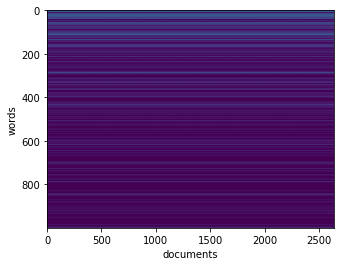

In [228]:
plt.imshow(C,aspect=2);
plt.xlabel('documents');
plt.ylabel('words');
print('sparsity =',np.sum(C)/(C.shape[0]*C.shape[1]))

### Run PCA
We initialize the scikit learn implementation of PCA to return as many principal components as possible. The number of principal components we can compute is equal to the number of rows or columns, depending on which one is smaller. Here, we have 1000 unique words (rows) in 2636 pages, so the maximum number of principal components = 1000.

Fitting all the principal components enables use to plot the cumulative contribution of all pricincipal components and decide how many should be retain to vectorize the words in our corpus. 

In [229]:
pca = PCA(n_components=np.min([len(unique_words),len(pages)]))
pca.fit(C);

### Plot the explained variance
We plot the explained variance of each principal component, as well the as cumulative amount of explained variance for each component added. By design, PCA returns its pricinpal components sorted. We can use cumulative amount of explained variance to determine how many of the components account for 99% of the explained variance and only retain those, so that our the vectorization of the words yields vectors in relatively low dimensional space, without loosing to much information in the process.

In this example, we only need 5 principal components. If we had a large corpus on the same topic, we would have been better at finding principal compoments that explained more variance, yielding a more complex and meaningful vectorization whre additional dimensions capture more fine grained meaning derived from the co-occurence of certain words. 

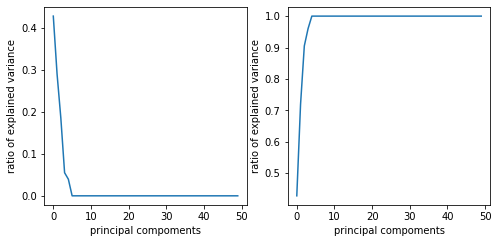

In [230]:
plt.figure(figsize=(8,8));
plt.subplot(2,2,1);
plt.plot(pca.explained_variance_ratio_[:50]);
plt.xlabel('principal compoments');
plt.ylabel('ratio of explained variance');
plt.subplot(2,2,2);
plt.plot(np.cumsum(pca.explained_variance_ratio_[:50]));
plt.xlabel('principal compoments');
plt.ylabel('ratio of explained variance');

### Vectorize the words
With the number of components we want to retain known, we can constrain the PC matrix provided by the scikit-learn algorithm.
After that, we project our original binary matrix C of co-occcurrences onto this PC matrix, yielding a matrix of scores, 
representing the mapping of each word onto a 5 dimensional vector. 

As a short cut, we can also re-run the sci-kit learn algorithm with the right number components, and use the fit_transform function. 
This will do all the computation described above on our behalf. 


In [231]:
cutoff = np.where(np.cumsum(pca.explained_variance_ratio_) > 0.99)[0][0]
pca_transformed = PCA(n_components=cutoff);
vectors = pca_transformed.fit_transform(C);

### Sanity Check
If we were succesfull in created a meaningful word to vector mapping, words that are similar in meaning or at least in affinity to a topic map to similar vectors. A useful metric for computed vector similary is the cosine distance. This distance metric compute the angle between the two vectors, disregarding their lengths. Small angles mean the vector point in similar directions, and can thus be considered similar themselves.

### Pairwise Cosine Distances
Compute all pairwise distances between vectors. After that, remove all pairs for which row_inde==column_index as these
represent the distance between a word and itself. 

In [232]:
D = squareform(pdist(vectors,'cosine'))
Dflat = D.flatten()
sorted_indices = np.argsort(Dflat)
sorted_distances = np.sort(Dflat)
sorted_pairs_tuple = np.unravel_index(sorted_indices, D.shape, order='C')
sorted_pairs = np.zeros((len(unique_words)**2,2))
sorted_pairs[:,0] = sorted_pairs_tuple[0]
sorted_pairs[:,1] = sorted_pairs_tuple[1]
valid_pairs_indices = np.where(sorted_pairs[:,0] != sorted_pairs[:,1])
valid_pairs = np.squeeze(sorted_pairs[valid_pairs_indices,:])
valid_distances = sorted_distances[valid_pair_indices]

### Distance Comparison
Pick the top 10 largest and top 10 smallest distances for comparison

In [234]:
for i in range(20):
    word_index1 = int(valid_pairs[i,0])
    word_index2 = int(valid_pairs[i,1])
    print(word_index1)
    word1 = unique_words[word_index1]
    word2 = unique_words[word_index2]
    print(word1,word2)

607
tools various
607
tools reach
607
tools metastases
607
tools single
607
tools allow
607
tools nervous
607
tools staff
607
tools histiocytosis
607
tools radioactive
607
tools examination
607
tools exposure
607
tools syndrome
607
tools 1
607
tools bleeding
607
tools confirm
607
tools hundreds
607
tools compassionate
607
tools malignant
607
tools reconstruction
607
tools affects
